In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("StudentsPerformance.csv")
df.head()

Saving StudentsPerformance.csv to StudentsPerformance.csv


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score               

In [ ]:
df["Pass"] = (df["math score"] >= 50).astype(int)

df["Pass"].value_counts()


,count
Pass,
1,865
0,135


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Pass
0,0,1,1,1,1,72,72,74,1
1,0,2,4,1,0,69,90,88,1
2,0,1,3,1,1,90,95,93,1
3,1,0,0,0,1,47,57,44,0
4,1,2,4,1,1,76,78,75,1


In [ ]:
X = df.drop(["Pass","math score"], axis=1)
y = df["Pass"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Done")

Done


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.865


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.50      0.57        34
           1       0.90      0.95      0.92       166

    accuracy                           0.87       200
   macro avg       0.78      0.72      0.75       200
weighted avg       0.86      0.87      0.86       200



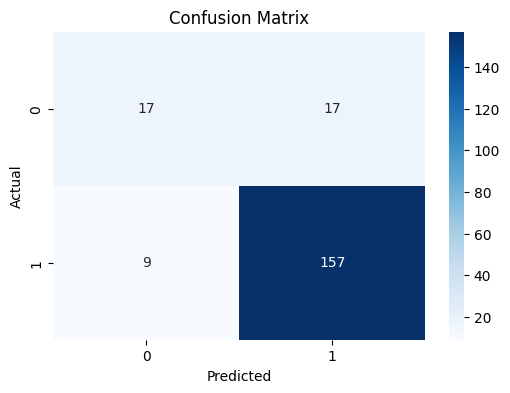

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

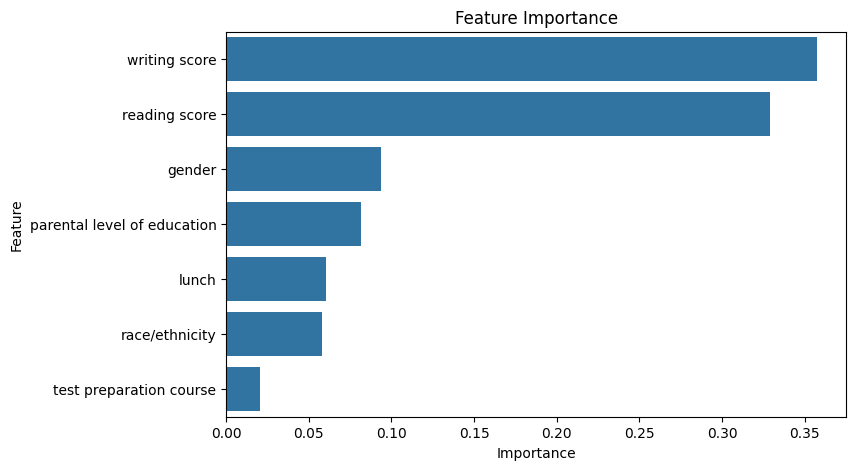

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

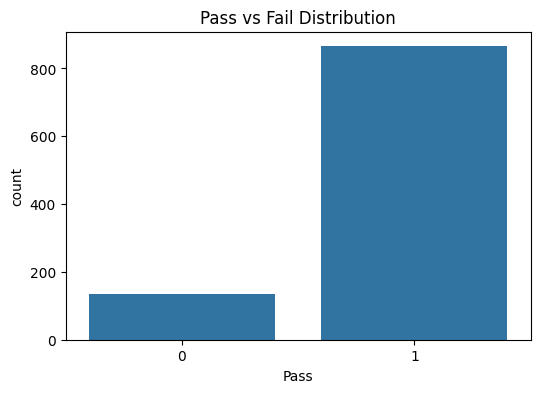

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pass', data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

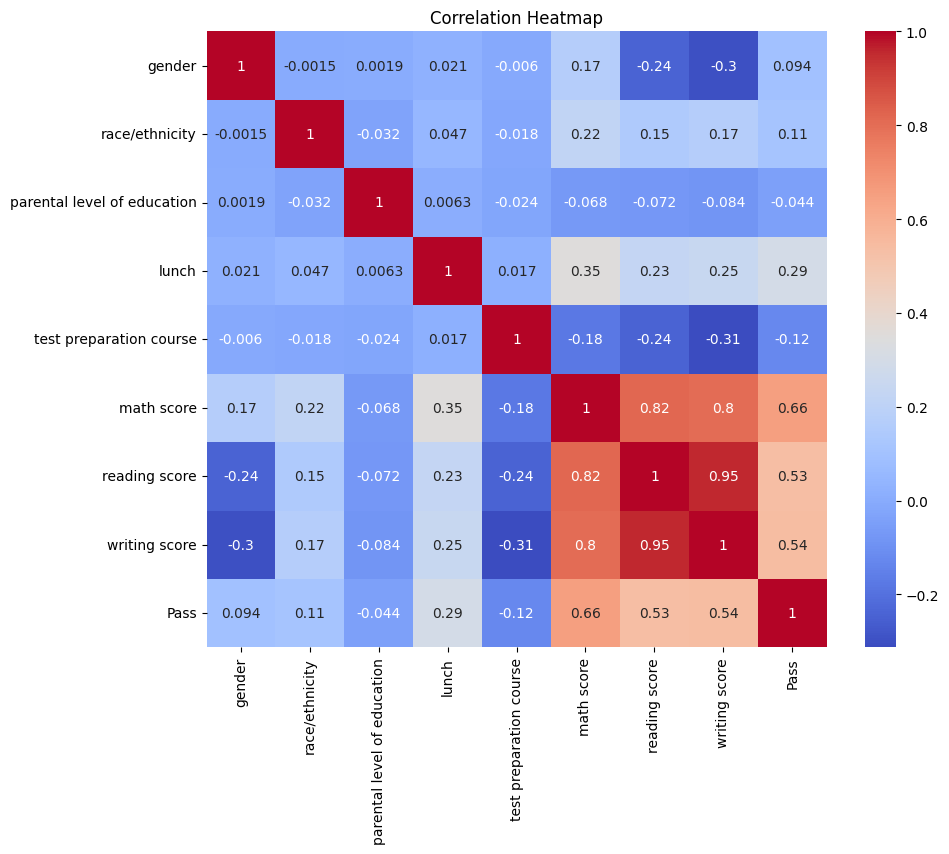

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

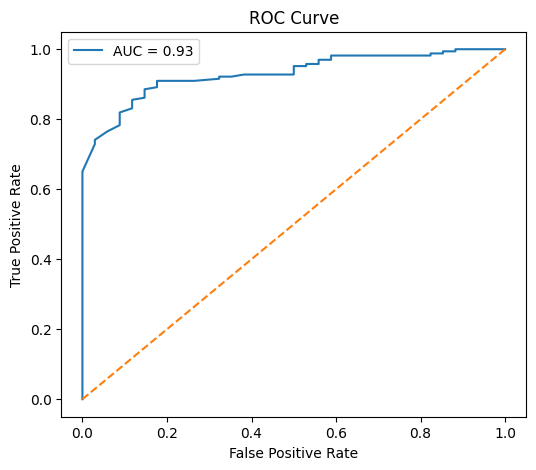

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, pred)

print(results)

{'Logistic Regression': 0.89, 'Decision Tree': 0.855, 'Random Forest': 0.865}


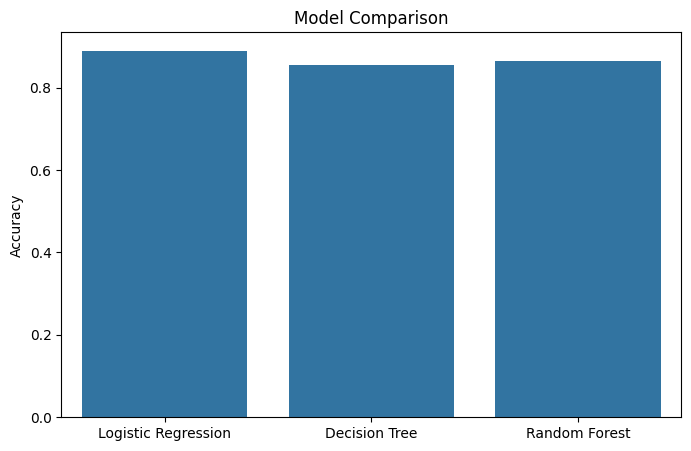

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=list(results.keys()),
    y=list(results.values())
)

plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
new_student = [[1,2,1,0,1,65,72]]

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Student is likely to PASS")
else:
    print("Student is likely to FAIL")

Student is likely to PASS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

joblib.dump(model,'student_performance_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    RandomForestClassifier(),
    X,
    y,
    cv=5
)

print(scores)
print("Average Accuracy:", scores.mean())

[0.925 0.92  0.92  0.885 0.895]
Average Accuracy: 0.909


In [ ]:
importance.sort_values(
    by='Importance',
    ascending=False
)
importance.to_csv(
    "Feature_Importance.csv",
    index=False
)

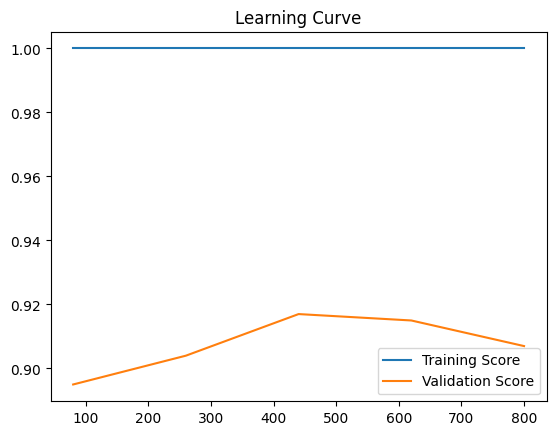

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5
)

plt.plot(
    train_sizes,
    np.mean(train_scores, axis=1),
    label="Training Score"
)

plt.plot(
    train_sizes,
    np.mean(test_scores, axis=1),
    label="Validation Score"
)

plt.legend()
plt.title("Learning Curve")
plt.show()